# What is this data?

The audit notebook (`full_data_audit.ipynb`) answers *"is this dataset correct?"* — 39 checks, a
pass/fail table, no story. This notebook answers the other question: **what does the data actually
look like, and what is the model being asked to do?**

Nothing here is a check. It is here to be *looked at*.

---

## The one-paragraph version

A single MRI voxel is not one tissue. It is a **mixture of microscopic water pools** — myelin
water, water inside and outside cells, CSF — and each pool relaxes at its own speed, described by
two numbers: **T1** (how fast it recovers) and **T2** (how fast it decays). The scanner does not
see the pools. It sees **64 numbers**: their summed signal, measured at 8 inversion times (TI) ×
8 echo times (TE), buried in noise.

**The model's job: from those 64 noisy numbers, recover the pools.** How many, and each one's
(T1, T2, weight). That is what every row of this dataset is — 64 numbers in, a set of pools out.

In [1]:
import os, sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src")); sys.path.insert(0, str(ROOT / "voxel_generator" / "src"))
os.chdir(ROOT)

import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from IPython.display import Image
from t1t2.physics import load_protocol, forward_numpy

DATA = Path("data/full_1to4")
FIG = ROOT / "results" / "data_overview"; FIG.mkdir(parents=True, exist_ok=True)
proto = load_protocol()

# n_comp is ordinal (1 < 2 < 3 < 4), so it gets a single-hue ramp rather than four unrelated
# colours: darker = more pools = harder. Validated for lightness monotonicity, step gaps, single
# hue, and contrast against a light surface.
NCOL = {1: "#6baed6", 2: "#4292c6", 3: "#2171b5", 4: "#08306b"}
INK, MUTED = "#1a1a19", "#6b6b68"
mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,   # recessive frame
    "grid.color": "#e8e8e6", "grid.linewidth": 0.8, "font.size": 10,
})
print(f"protocol: {proto.n_points} points = {len(np.unique(proto.ti))} TI x {len(np.unique(proto.te))} TE")
print(f"data    : {DATA}")

protocol: 64 points = 8 TI x 8 TE
data    : data/full_1to4


## 1. One voxel, from pools to 64 numbers

Here is a real voxel from the dataset — a **2-pool** one. Read it left to right: two water pools
exist (left), each contributes its own curve (middle), and the scanner only ever sees their
**sum plus noise** (right).

The middle panel is the whole difficulty of this thesis in one picture. The two curves are
individually simple. Their sum is not obviously two things. **Undoing that sum is the problem.**

this voxel:
  pool 1: T1=   315 ms   T2=   22 ms   weight=0.66
  pool 2: T1=  3755 ms   T2=  408 ms   weight=0.34

the model sees only the 64 pink dots. It must output the two circles on the left.


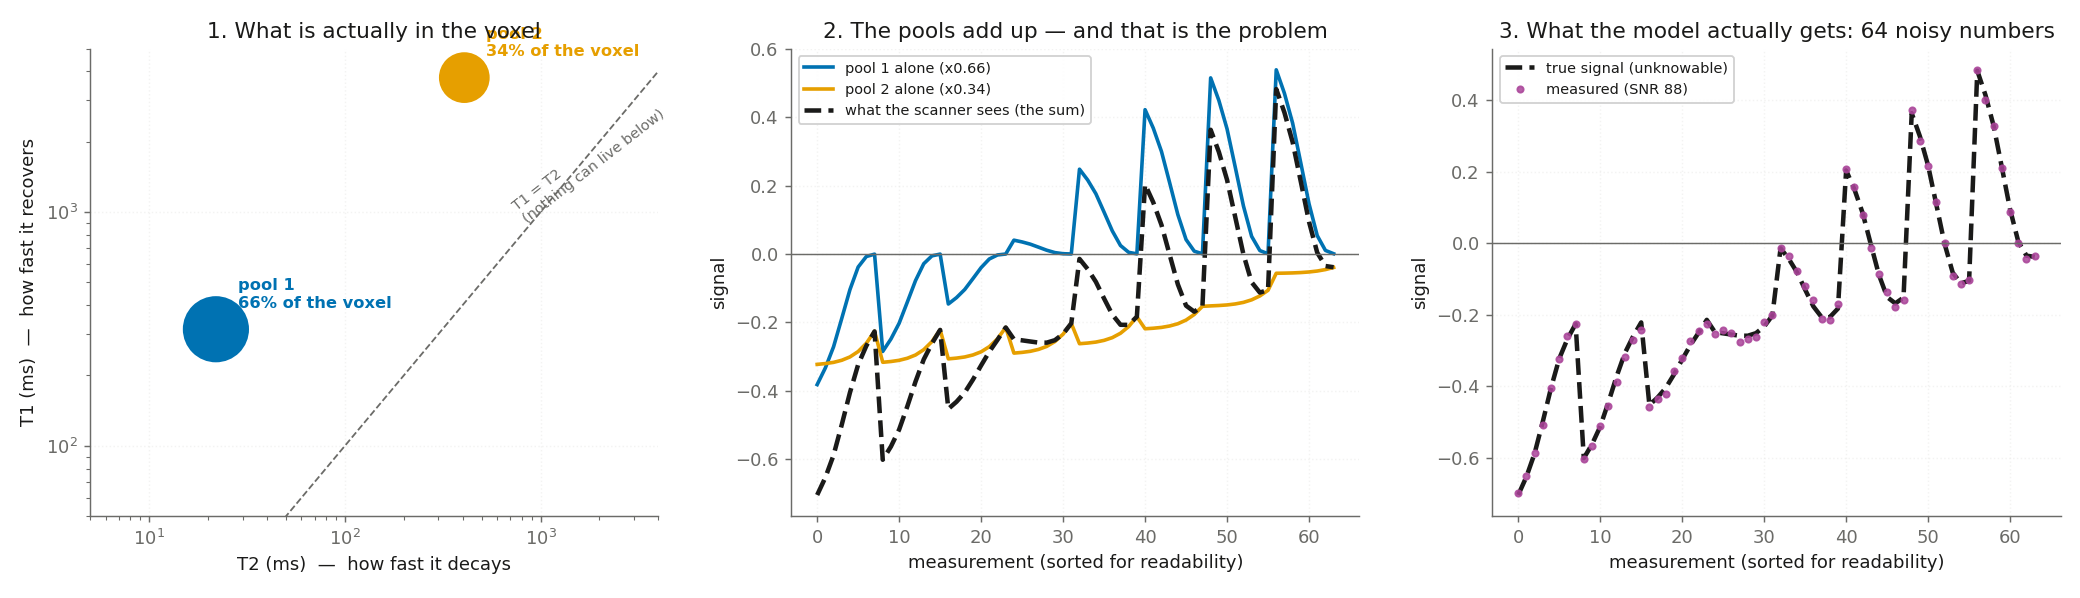

In [2]:
d = pd.read_parquet(DATA / "n2" / "train.parquet").iloc[3]
n = int(d.n_comp)
t1 = d[[f"T1_{i+1}" for i in range(n)]].to_numpy(float)
t2 = d[[f"T2_{i+1}" for i in range(n)]].to_numpy(float)
w  = d[[f"w_{i+1}"  for i in range(n)]].to_numpy(float)
S  = d[[f"S_{i+1}" for i in range(64)]].to_numpy(float)
clean = forward_numpy(proto, t1, t2, w)

POOL_C = ["#0072B2", "#E69F00"]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))

# --- what is in the voxel
ax[0].scatter(t2, t1, s=[300 + 1800*x for x in w], c=POOL_C[:n], edgecolor="white",
              linewidth=2, zorder=3)
for i in range(n):
    ax[0].annotate(f"pool {i+1}\n{w[i]*100:.0f}% of the voxel",
                   (t2[i], t1[i]), xytext=(12, 12), textcoords="offset points",
                   fontsize=9, color=POOL_C[i], fontweight="bold")
ax[0].plot([5, 4000], [5, 4000], "--", color=MUTED, lw=1)
ax[0].text(700, 900, "T1 = T2\n(nothing can live below)", fontsize=8, color=MUTED, rotation=38)
ax[0].set(xscale="log", yscale="log", xlim=(5, 4000), ylim=(50, 5000),
          xlabel="T2 (ms)  —  how fast it decays", ylabel="T1 (ms)  —  how fast it recovers",
          title="1. What is actually in the voxel")
ax[0].grid(True, which="major", ls=":", alpha=0.5)

# --- each pool's contribution, and the sum
order = np.argsort(proto.ti + proto.te / 1000)      # a readable sweep, not scanner order
for i in range(n):
    solo = forward_numpy(proto, t1[i:i+1], t2[i:i+1], np.array([1.0])) * w[i]
    ax[1].plot(solo[order], color=POOL_C[i], lw=2, label=f"pool {i+1} alone (x{w[i]:.2f})")
ax[1].plot(clean[order], color=INK, lw=2.5, ls="--", label="what the scanner sees (the sum)")
ax[1].axhline(0, color=MUTED, lw=0.8)
ax[1].set(xlabel="measurement (sorted for readability)", ylabel="signal",
          title="2. The pools add up — and that is the problem")
ax[1].legend(fontsize=8, framealpha=0.9); ax[1].grid(True, ls=":", alpha=0.5)

# --- plus noise: what the model is handed
ax[2].plot(clean[order], color=INK, lw=2.5, ls="--", label="true signal (unknowable)")
ax[2].plot(S[order], "o", color="#AA4499", ms=3.5, alpha=0.85, label=f"measured (SNR {d.snr:.0f})")
ax[2].axhline(0, color=MUTED, lw=0.8)
ax[2].set(xlabel="measurement (sorted for readability)", ylabel="signal",
          title="3. What the model actually gets: 64 noisy numbers")
ax[2].legend(fontsize=8, framealpha=0.9); ax[2].grid(True, ls=":", alpha=0.5)

fig.tight_layout(); fig.savefig(FIG / "01_one_voxel.png", dpi=130); plt.close(fig)
print("this voxel:")
for i in range(n):
    print(f"  pool {i+1}: T1={t1[i]:6.0f} ms   T2={t2[i]:5.0f} ms   weight={w[i]:.2f}")
print(f"\nthe model sees only the 64 pink dots. It must output the two circles on the left.")
Image(filename=str(FIG / "01_one_voxel.png"))

## 2. Why 8 × 8? What the two axes are for

The 64 measurements are a **grid**, not a list. Each axis interrogates one relaxation time:

- **TI (inversion time)** — walk down the rows and the signal recovers from negative to positive.
  *How fast it flips sign tells you T1.*
- **TE (echo time)** — walk across the columns and the signal decays toward zero.
  *How fast it fades tells you T2.*

That is why a single voxel needs a 2-D grid: one axis alone could not separate the two.

**The red half of this map is real.** Right after the inversion pulse the signal is genuinely
negative — which is why this data is *signed*, and why the noise model is plain Gaussian rather
than the magnitude (Rician) model used for ordinary MRI images. Getting that wrong would erase
half the information.

negative measurements in this voxel: 51 of 64 — not an artifact, physics.


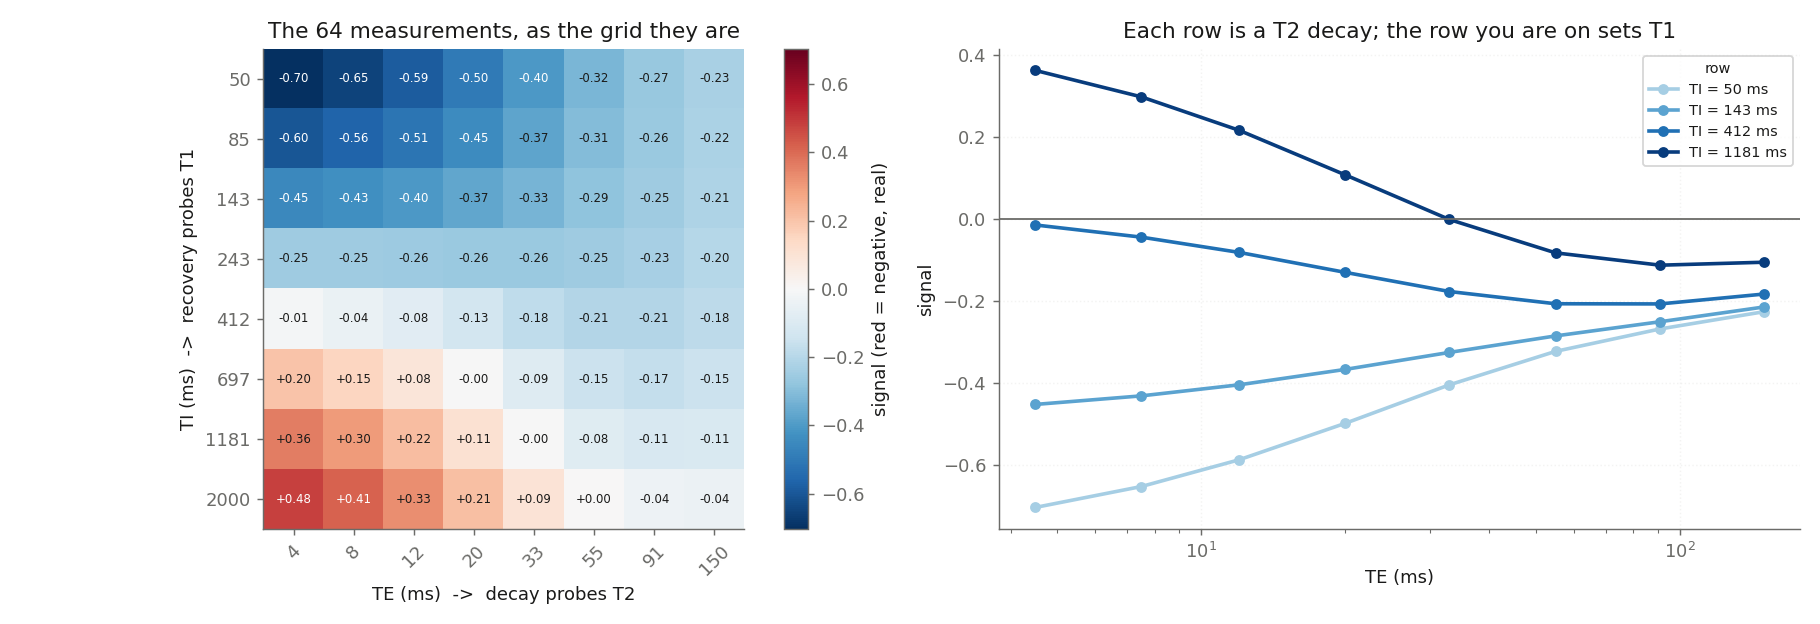

In [3]:
uti, ute = np.unique(proto.ti), np.unique(proto.te)
def grid_of(sig):
    g = np.full((8, 8), np.nan)
    for p in range(64):
        g[int(np.argmin(abs(uti - proto.ti[p]))), int(np.argmin(abs(ute - proto.te[p])))] = sig[p]
    return g

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
g = grid_of(clean)
m = np.nanmax(np.abs(g))
# Diverging: the signal is signed and zero is meaningful, so two hues around a neutral midpoint.
im = ax[0].imshow(g, cmap="RdBu_r", vmin=-m, vmax=m)
for i in range(8):
    for j in range(8):
        ax[0].text(j, i, f"{g[i,j]:+.2f}", ha="center", va="center", fontsize=6.5,
                   color="white" if abs(g[i,j]) > m*0.55 else INK)
ax[0].set(xticks=range(8), yticks=range(8),
          xlabel="TE (ms)  ->  decay probes T2", ylabel="TI (ms)  ->  recovery probes T1",
          title="The 64 measurements, as the grid they are")
ax[0].set_xticklabels([f"{t:.0f}" for t in ute], rotation=45)
ax[0].set_yticklabels([f"{t:.0f}" for t in uti])
fig.colorbar(im, ax=ax[0], fraction=0.046, label="signal (red = negative, real)")

for k, i in enumerate(range(0, 8, 2)):
    ax[1].plot(ute, g[i], "o-", ms=5, lw=2, color=plt.cm.Blues(0.35 + 0.2*k),
               label=f"TI = {uti[i]:.0f} ms")
ax[1].axhline(0, color=MUTED, lw=1)
ax[1].set(xscale="log", xlabel="TE (ms)", ylabel="signal",
          title="Each row is a T2 decay; the row you are on sets T1")
ax[1].legend(fontsize=8, title="row", title_fontsize=8); ax[1].grid(True, ls=":", alpha=0.5)
fig.tight_layout(); fig.savefig(FIG / "02_the_grid.png", dpi=130); plt.close(fig)
print(f"negative measurements in this voxel: {(clean < 0).sum()} of 64 — not an artifact, physics.")
Image(filename=str(FIG / "02_the_grid.png"))

## 3. What noise does — the same voxel, five times

This is the clearest picture of the task's difficulty, and it is only possible because of how the
dataset is built: the five fixed-SNR test sets contain **the same voxels with the same noise
pattern**, scaled. Same pools, same everything — *only the noise amplitude changes*.

So the differences below are **purely** the noise. Nothing else varies.

At SNR 150 the curve is obvious. At SNR 20 — which the model never trains on, it is deliberately
harder than anything it has seen — you are looking at what the model is asked to invert.

Training uses SNR 30-150 (random per voxel). SNR 20 sits *below* that on purpose:
it tests whether the model degrades gracefully outside what it was shown.


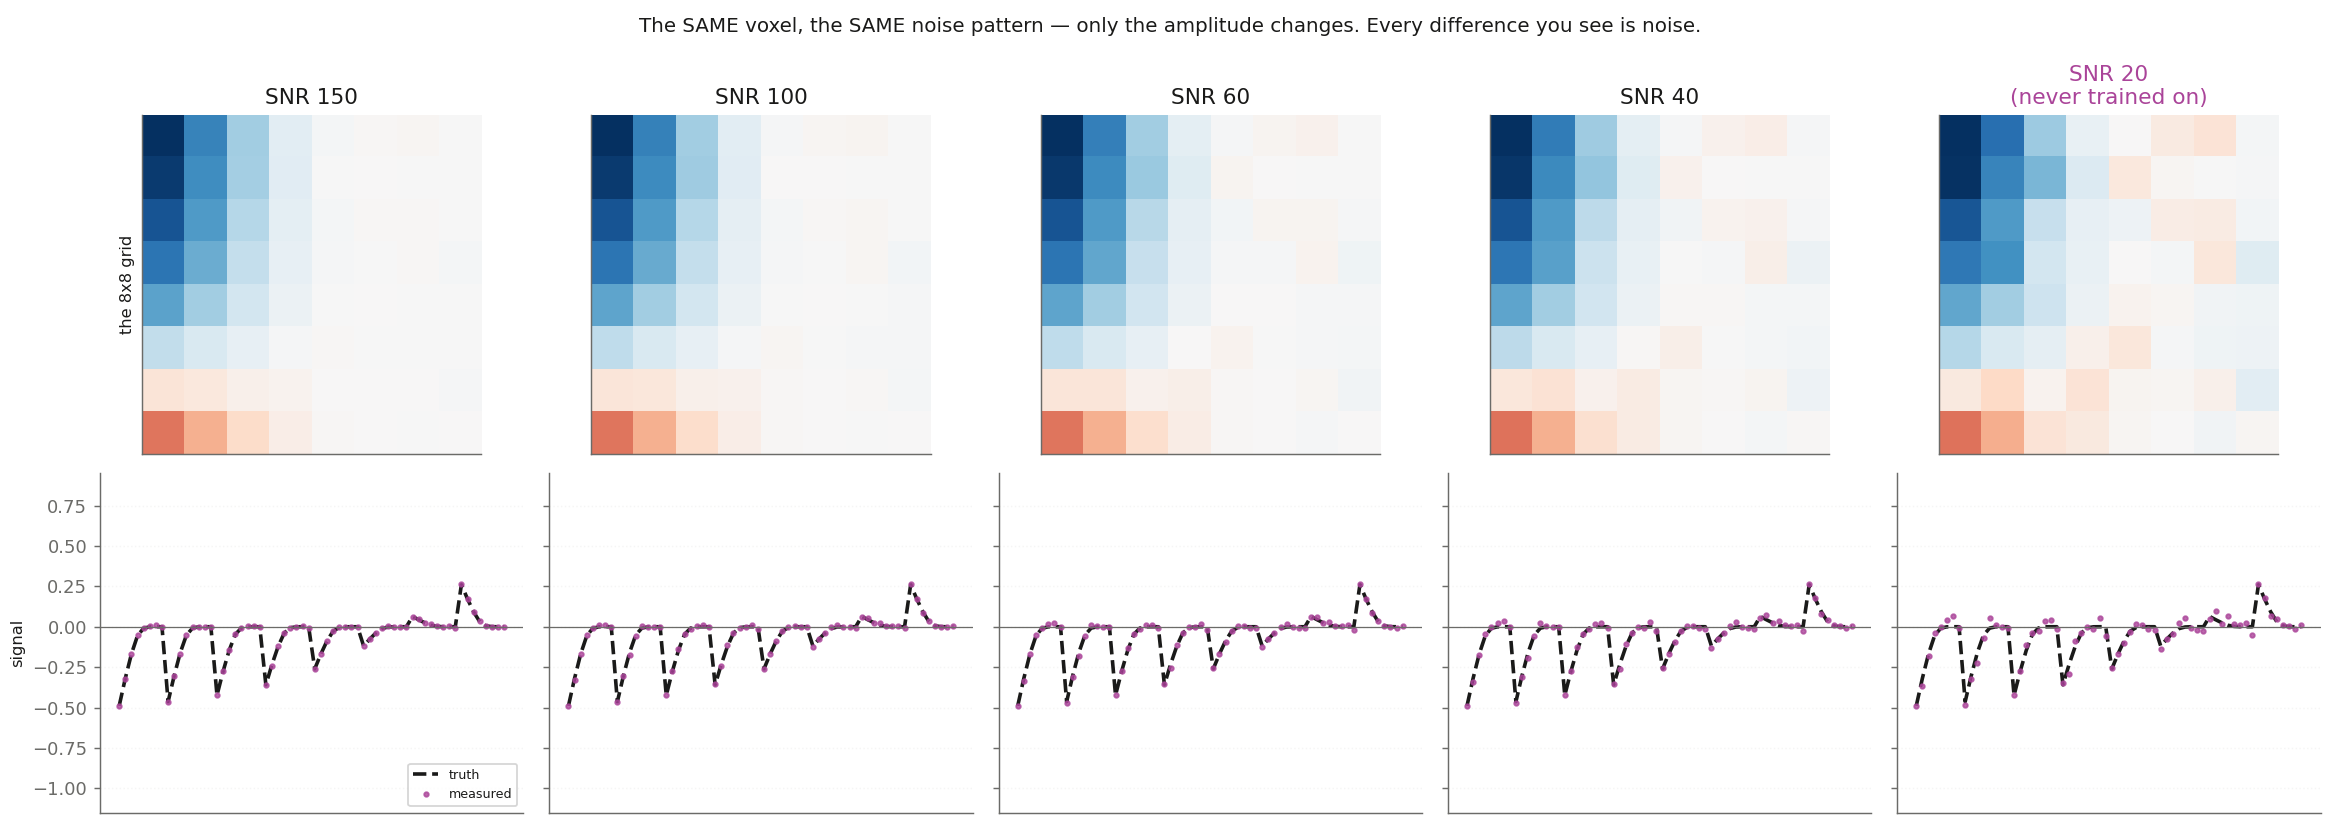

In [4]:
rungs = [150, 100, 60, 40, 20]
row = 5
fig, ax = plt.subplots(2, 5, figsize=(18, 6.4))
for k, snr in enumerate(rungs):
    dd = pd.read_parquet(DATA / "n2" / f"test_snr{snr}.parquet").iloc[row]
    nn = int(dd.n_comp)
    a1 = dd[[f"T1_{i+1}" for i in range(nn)]].to_numpy(float)
    a2 = dd[[f"T2_{i+1}" for i in range(nn)]].to_numpy(float)
    aw = dd[[f"w_{i+1}"  for i in range(nn)]].to_numpy(float)
    cl = forward_numpy(proto, a1, a2, aw)
    sg = dd[[f"S_{i+1}" for i in range(64)]].to_numpy(float)
    o = np.argsort(proto.ti + proto.te/1000)

    gg = grid_of(sg); mm = np.nanmax(np.abs(gg))
    ax[0, k].imshow(gg, cmap="RdBu_r", vmin=-mm, vmax=mm)
    ax[0, k].set(xticks=[], yticks=[], title=f"SNR {snr}" + ("\n(never trained on)" if snr == 20 else ""))
    ax[0, k].title.set_color("#AA4499" if snr == 20 else INK)

    ax[1, k].plot(cl[o], color=INK, lw=2, ls="--", label="truth")
    ax[1, k].plot(sg[o], "o", color="#AA4499", ms=2.5, alpha=0.8, label="measured")
    ax[1, k].axhline(0, color=MUTED, lw=0.7)
    ax[1, k].set(ylim=(-1.15, 0.95), xticks=[])
    ax[1, k].grid(True, ls=":", alpha=0.4)
    if k == 0:
        ax[0, k].set_ylabel("the 8x8 grid", fontsize=9)
        ax[1, k].set_ylabel("signal", fontsize=9)
        ax[1, k].legend(fontsize=7, loc="lower right")
    else:
        ax[1, k].set_yticklabels([])

fig.suptitle("The SAME voxel, the SAME noise pattern — only the amplitude changes. "
             "Every difference you see is noise.", fontsize=11)
fig.tight_layout(); fig.savefig(FIG / "03_what_noise_does.png", dpi=130); plt.close(fig)
print("Training uses SNR 30-150 (random per voxel). SNR 20 sits *below* that on purpose:")
print("it tests whether the model degrades gracefully outside what it was shown.")
Image(filename=str(FIG / "03_what_noise_does.png"))

## 4. One pool, or four? What the model has to tell apart

The dataset holds an equal number of voxels with **1, 2, 3 and 4 pools** — 250,000 each, exactly.
Below is one example of each: the pools on top, the signal they produce underneath.

Look at the bottom row. **The signals barely differ.** A 1-pool voxel and a 4-pool voxel produce
curves of much the same shape. That similarity — not the noise — is the deep difficulty: the
scanner's 64 numbers simply do not carry four pools' worth of separated information.

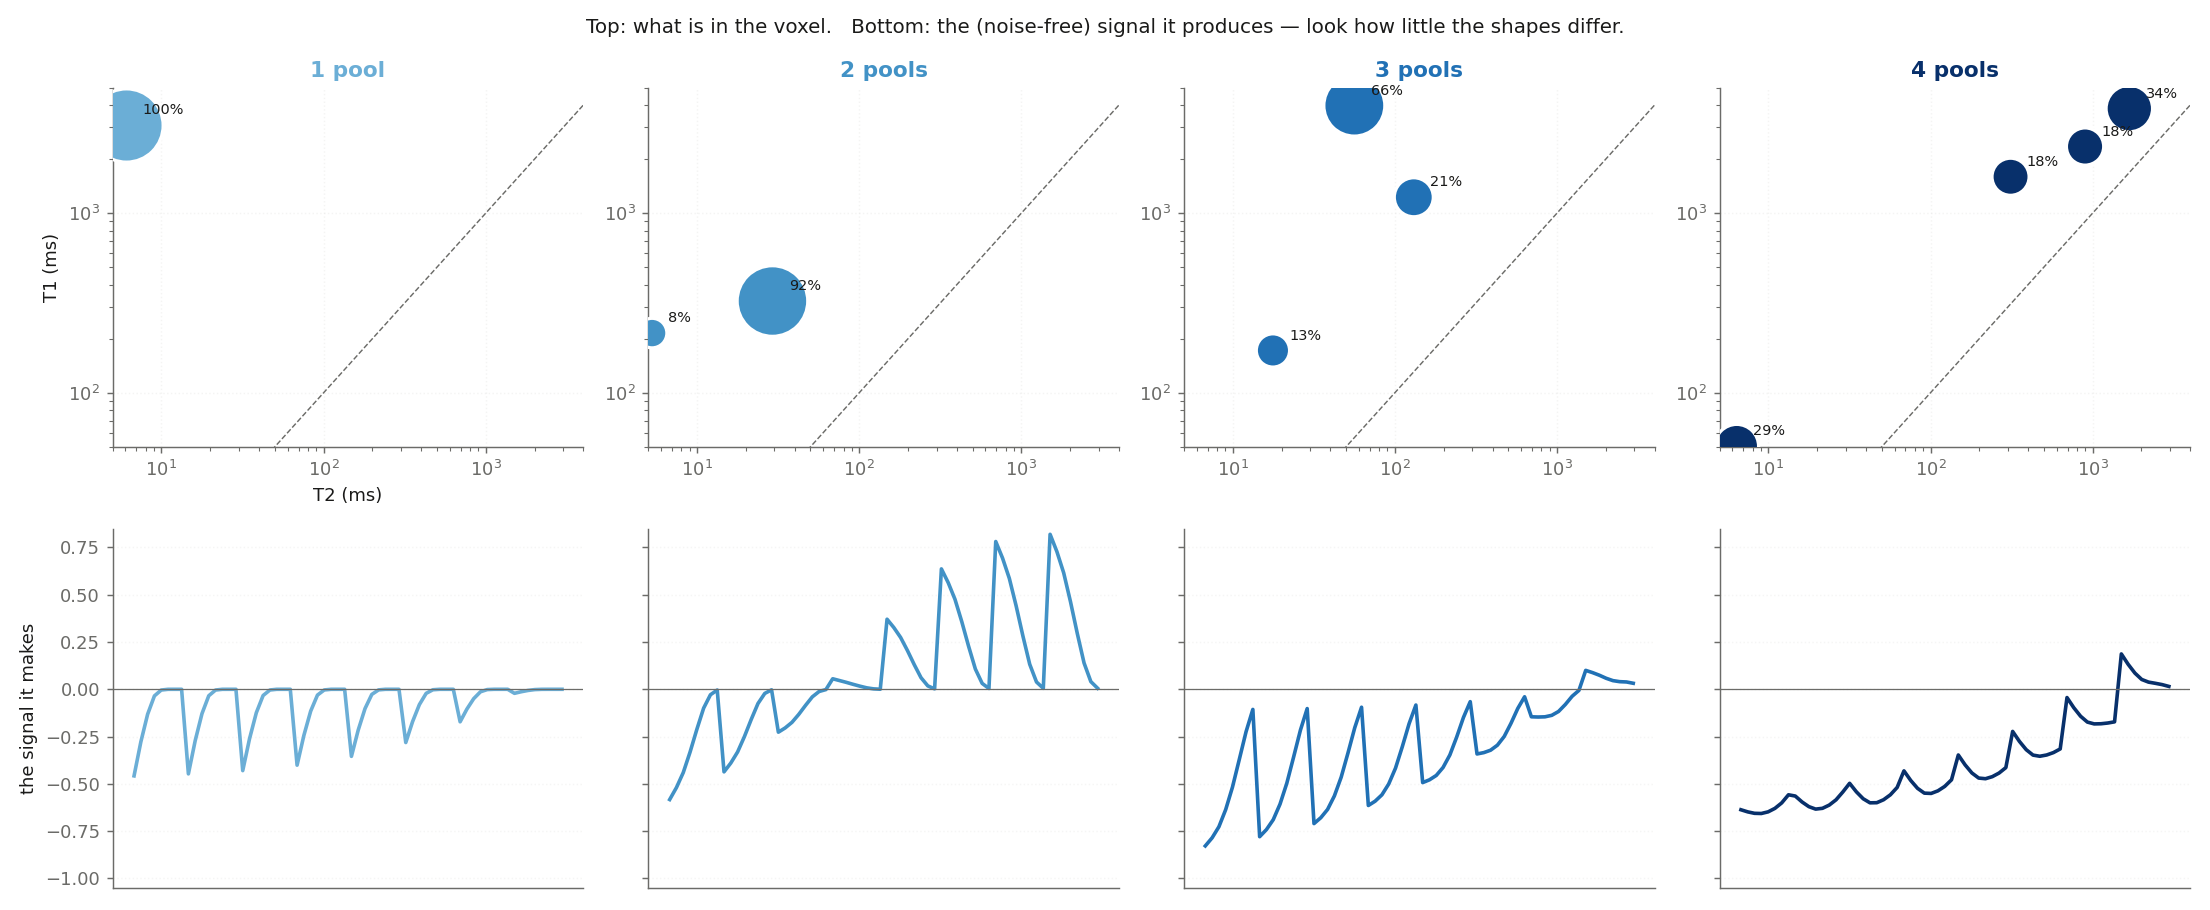

In [5]:
fig, ax = plt.subplots(2, 4, figsize=(17, 7))
o = np.argsort(proto.ti + proto.te/1000)
for n_c in (1, 2, 3, 4):
    k = n_c - 1
    dd = pd.read_parquet(DATA / f"n{n_c}" / "train.parquet").iloc[1]
    a1 = dd[[f"T1_{i+1}" for i in range(n_c)]].to_numpy(float)
    a2 = dd[[f"T2_{i+1}" for i in range(n_c)]].to_numpy(float)
    aw = dd[[f"w_{i+1}"  for i in range(n_c)]].to_numpy(float)
    cl = forward_numpy(proto, a1, a2, aw)

    ax[0, k].scatter(a2, a1, s=[150 + 1500*x for x in aw], c=NCOL[n_c],
                     edgecolor="white", linewidth=1.8, zorder=3)
    for i in range(n_c):
        ax[0, k].annotate(f"{aw[i]*100:.0f}%", (a2[i], a1[i]), xytext=(9, 6),
                          textcoords="offset points", fontsize=8, color=INK)
    ax[0, k].plot([5, 4000], [5, 4000], "--", color=MUTED, lw=0.8)
    ax[0, k].set(xscale="log", yscale="log", xlim=(5, 4000), ylim=(50, 5000),
                 title=f"{n_c} pool{'s' if n_c > 1 else ''}")
    ax[0, k].title.set_color(NCOL[n_c]); ax[0, k].title.set_fontweight("bold")
    ax[0, k].grid(True, which="major", ls=":", alpha=0.45)
    if k == 0:
        ax[0, k].set(xlabel="T2 (ms)", ylabel="T1 (ms)")

    ax[1, k].plot(cl[o], color=NCOL[n_c], lw=2)
    ax[1, k].axhline(0, color=MUTED, lw=0.7)
    ax[1, k].set(ylim=(-1.05, 0.85), xticks=[])
    ax[1, k].grid(True, ls=":", alpha=0.4)
    if k == 0:
        ax[1, k].set_ylabel("the signal it makes")
    else:
        ax[1, k].set_yticklabels([])

fig.suptitle("Top: what is in the voxel.   Bottom: the (noise-free) signal it produces — "
             "look how little the shapes differ.", fontsize=11)
fig.tight_layout(); fig.savefig(FIG / "04_one_pool_or_four.png", dpi=130); plt.close(fig)
Image(filename=str(FIG / "04_one_pool_or_four.png"))

## 5. Why 4 pools is genuinely hard — not the model's fault

Take a 4-pool voxel and simply **delete its smallest pool**. If the signal barely moves, then no
method — not this model, not any method — could have known that pool was there.

Left: the two signals, with and without the smallest pool. Right: how big that difference is
compared to the noise it hides under.

**When the orange band is inside the grey band, the pool is invisible.** This is a property of the
physics and the protocol, not of the network. It is the *ceiling* on what any method can score.

SNR 150: the pool moves the signal by a median of 1.08x the noise -> visible
SNR  20: the pool moves the signal by a median of 0.14x the noise -> INVISIBLE


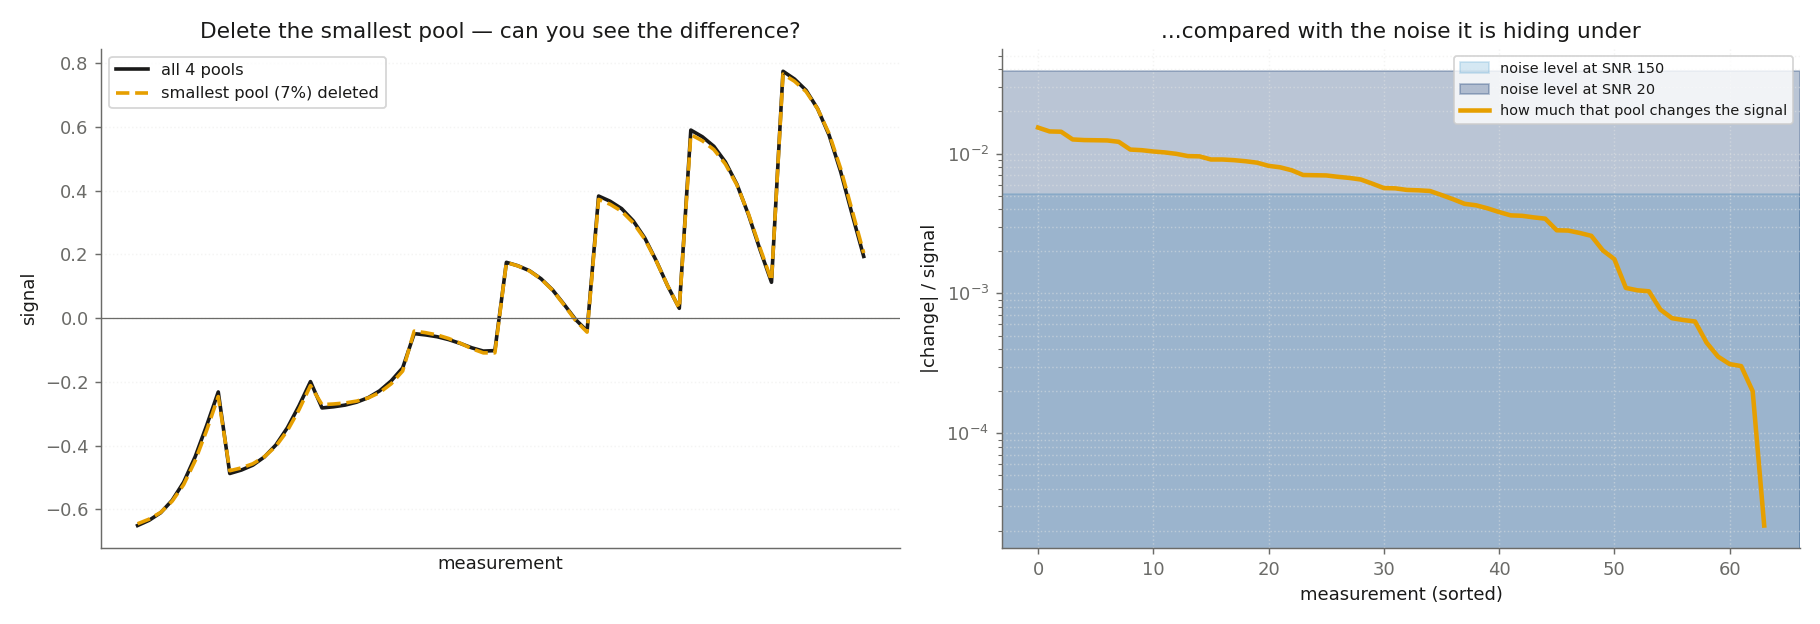

In [6]:
dd = pd.read_parquet(DATA / "n4" / "train.parquet")
# pick a voxel with a genuinely small pool, to show the typical hard case rather than a freak one
smallest = dd[[f"w_{i+1}" for i in range(4)]].min(axis=1)
idx = int(np.argsort(np.abs(smallest.to_numpy() - 0.07))[0])
r = dd.iloc[idx]
a1 = r[[f"T1_{i+1}" for i in range(4)]].to_numpy(float)
a2 = r[[f"T2_{i+1}" for i in range(4)]].to_numpy(float)
aw = r[[f"w_{i+1}"  for i in range(4)]].to_numpy(float)
full = forward_numpy(proto, a1, a2, aw)
j = int(np.argmin(aw))
keep = np.ones(4, bool); keep[j] = False
red = forward_numpy(proto, a1[keep], a2[keep], aw[keep]/aw[keep].sum())
diff = np.abs(full - red)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
ax[0].plot(full[o], color=INK, lw=2, label=f"all 4 pools")
ax[0].plot(red[o], color="#E69F00", lw=2, ls="--", label=f"smallest pool ({aw[j]*100:.0f}%) deleted")
ax[0].axhline(0, color=MUTED, lw=0.7)
ax[0].set(xticks=[], xlabel="measurement", ylabel="signal",
          title="Delete the smallest pool — can you see the difference?")
ax[0].legend(fontsize=9); ax[0].grid(True, ls=":", alpha=0.45)

for snr, col in ((150, "#6baed6"), (20, "#08306b")):
    sigma = np.max(np.abs(full)) / snr
    ax[1].axhspan(0, sigma, color=col, alpha=0.28,
                  label=f"noise level at SNR {snr}")
ax[1].plot(np.sort(diff)[::-1], color="#E69F00", lw=2.5, label="how much that pool changes the signal")
ax[1].set(yscale="log", xlabel="measurement (sorted)", ylabel="|change| / signal",
          title="...compared with the noise it is hiding under")
ax[1].legend(fontsize=8, loc="upper right"); ax[1].grid(True, which="both", ls=":", alpha=0.45)

fig.tight_layout(); fig.savefig(FIG / "05_why_four_is_hard.png", dpi=130); plt.close(fig)
for snr in (150, 20):
    s = np.max(np.abs(full)) / snr
    print(f"SNR {snr:3}: the pool moves the signal by a median of {np.median(diff)/s:.2f}x the noise "
          f"-> {'visible' if np.median(diff)/s > 1 else 'INVISIBLE'}")
Image(filename=str(FIG / "05_why_four_is_hard.png"))

### How often is that the case? (measured on the real data)

Not a special example — this is the whole dataset. The bar is the fraction of voxels whose
smallest pool is **below the noise floor** at SNR 20, i.e. voxels where the true count is simply
not recoverable.

This is why every result in the thesis is reported **per pool-count**. An average over 1–4 pools
mixes an easy regime with a near-impossible one and describes neither.

  2 pools:  27.4% of voxels have an invisible pool at SNR 20
  3 pools:  47.8% of voxels have an invisible pool at SNR 20
  4 pools:  69.3% of voxels have an invisible pool at SNR 20

=> a low score at 4 pools is the data's ceiling, not a broken model.


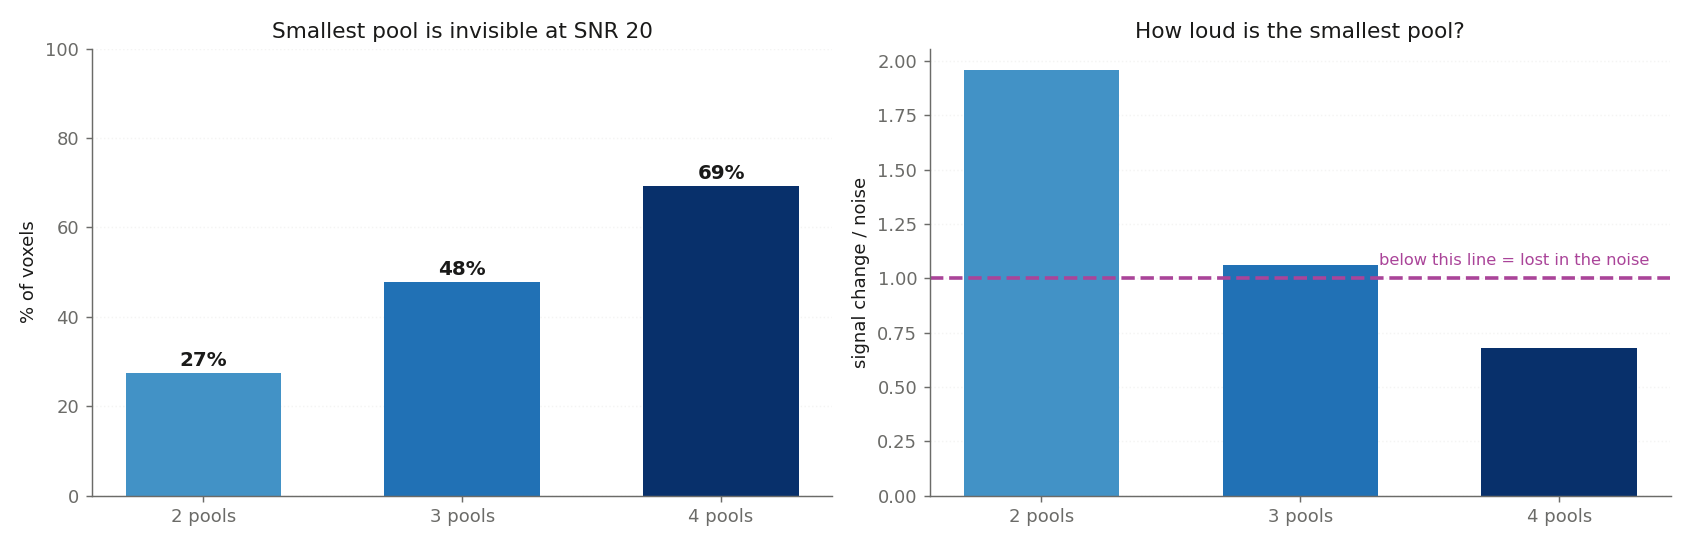

In [7]:
import json
aud = json.load(open("results/data_audit/full_1to4/audit_summary.json"))
ident = {r["n"]: r for r in aud["identifiability"]}
ns = [n for n in (2, 3, 4) if ident.get(n, {}).get("frac_below_noise_floor") is not None]
vals = [ident[n]["frac_below_noise_floor"] * 100 for n in ns]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
b = ax[0].bar([f"{n} pools" for n in ns], vals, color=[NCOL[n] for n in ns], width=0.6)
for rect, v in zip(b, vals):
    ax[0].text(rect.get_x() + rect.get_width()/2, v + 1.5, f"{v:.0f}%", ha="center",
               fontsize=11, fontweight="bold", color=INK)
ax[0].set(ylim=(0, 100), ylabel="% of voxels", title="Smallest pool is invisible at SNR 20")
ax[0].grid(True, axis="y", ls=":", alpha=0.45); ax[0].set_axisbelow(True)

ratio = [ident[n]["delta_over_sigma_median@SNR20"] for n in ns]
ax[1].bar([f"{n} pools" for n in ns], ratio, color=[NCOL[n] for n in ns], width=0.6)
ax[1].axhline(1, color="#AA4499", lw=2, ls="--")
ax[1].text(2.35, 1.06, "below this line = lost in the noise", fontsize=9, color="#AA4499",
           ha="right")
ax[1].set(ylabel="signal change / noise", title="How loud is the smallest pool?")
ax[1].grid(True, axis="y", ls=":", alpha=0.45); ax[1].set_axisbelow(True)

fig.tight_layout(); fig.savefig(FIG / "06_the_ceiling.png", dpi=130); plt.close(fig)
for n in ns:
    print(f"  {n} pools: {ident[n]['frac_below_noise_floor']*100:5.1f}% of voxels have an invisible pool at SNR 20")
print("\n=> a low score at 4 pools is the data's ceiling, not a broken model.")
Image(filename=str(FIG / "06_the_ceiling.png"))

## 6. Where the pools live

Every pool in the dataset is a random point in this space, subject to one physical rule: **T1 > T2**
(a pool cannot decay slower than it recovers). Nothing else — no tissue types, no realism. The
model is being trained to find pools *anywhere*, not to recognise brain tissue.

The triangle shape is that rule. The density is even inside it, which took some care: the obvious
way to enforce T1 > T2 quietly crowds the short-T1 corner.

T1 spans 50-4000 ms, T2 spans 5-3000 ms
every single pool obeys T1 > T2: True


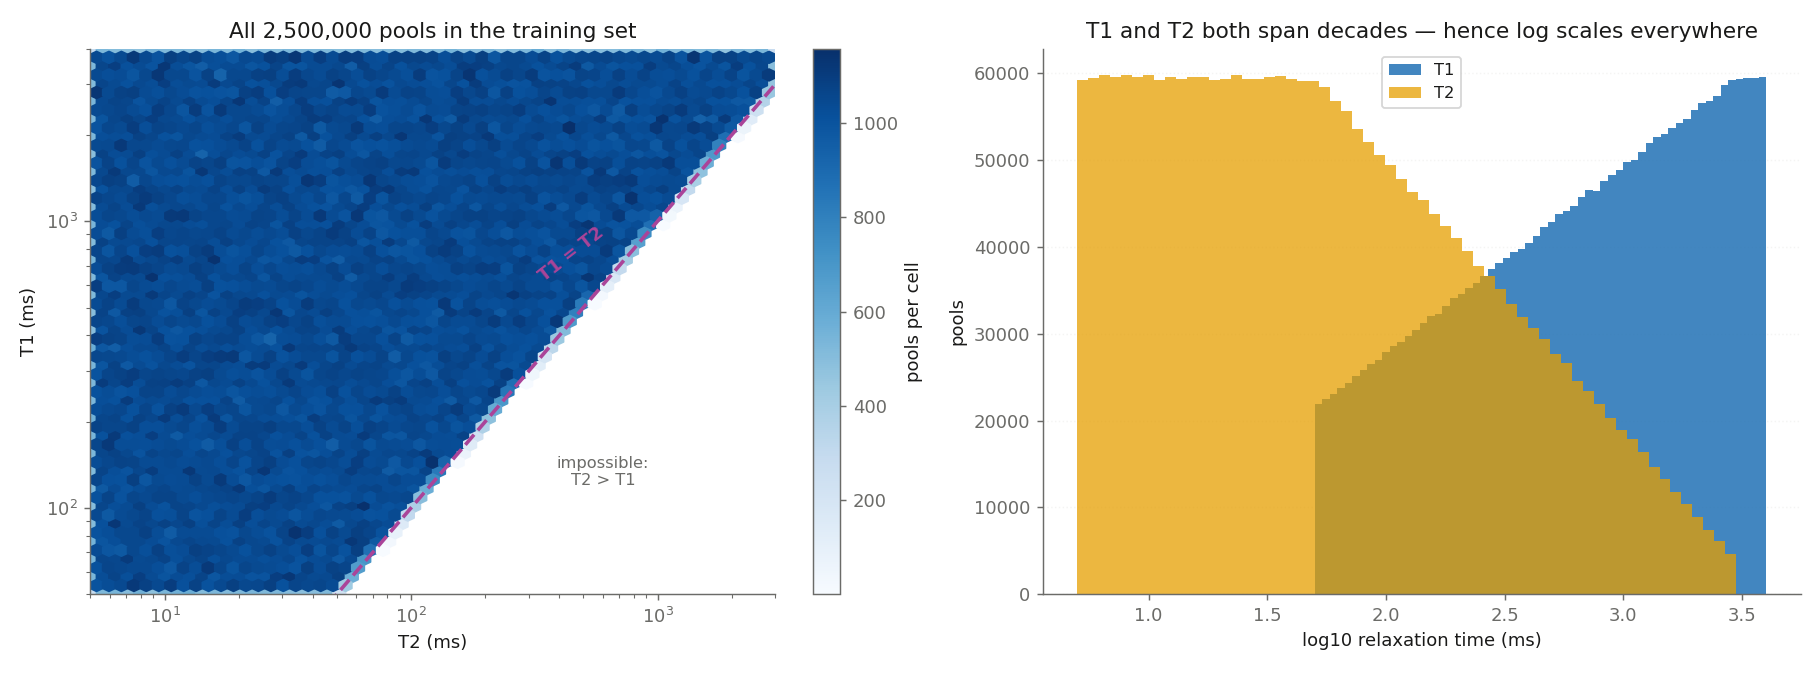

In [8]:
t1a, t2a = [], []
for n_c in (1, 2, 3, 4):
    dd = pd.read_parquet(DATA / f"n{n_c}" / "train.parquet", columns=[f"T1_{i+1}" for i in range(n_c)] + [f"T2_{i+1}" for i in range(n_c)])
    for i in range(n_c):
        t1a.append(dd[f"T1_{i+1}"].to_numpy()); t2a.append(dd[f"T2_{i+1}"].to_numpy())
t1a, t2a = np.concatenate(t1a), np.concatenate(t2a)

fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))
# Sequential: this is magnitude (how many pools land here), so one hue, light -> dark.
hb = ax[0].hexbin(t2a, t1a, xscale="log", yscale="log", gridsize=55, cmap="Blues", mincnt=1)
ax[0].plot([5, 4000], [5, 4000], color="#AA4499", ls="--", lw=2)
ax[0].text(320, 620, "T1 = T2", color="#AA4499", fontsize=10, rotation=38, fontweight="bold")
ax[0].text(600, 120, "impossible:\nT2 > T1", color=MUTED, fontsize=9, ha="center")
ax[0].set(xscale="log", yscale="log", xlim=(5, 3000), ylim=(50, 4000),
          xlabel="T2 (ms)", ylabel="T1 (ms)",
          title=f"All {len(t1a):,} pools in the training set")
fig.colorbar(hb, ax=ax[0], fraction=0.046, label="pools per cell")

ax[1].hist(np.log10(t1a), bins=60, color="#2171b5", alpha=0.85, label="T1")
ax[1].hist(np.log10(t2a), bins=60, color="#E69F00", alpha=0.75, label="T2")
ax[1].set(xlabel="log10 relaxation time (ms)", ylabel="pools",
          title="T1 and T2 both span decades — hence log scales everywhere")
ax[1].legend(fontsize=9); ax[1].grid(True, axis="y", ls=":", alpha=0.45); ax[1].set_axisbelow(True)
fig.tight_layout(); fig.savefig(FIG / "07_where_pools_live.png", dpi=130); plt.close(fig)
print(f"T1 spans {t1a.min():.0f}-{t1a.max():.0f} ms, T2 spans {t2a.min():.0f}-{t2a.max():.0f} ms")
print(f"every single pool obeys T1 > T2: {bool((t1a > t2a).all())}")
Image(filename=str(FIG / "07_where_pools_live.png"))

## 7. The dataset you will train on

Four files per split — one per pool count — so the mix is **exactly** balanced, not balanced on
average. Val and test are separate voxels the model never sees during training; the five SNR sets
are the same voxels at controlled noise levels, used only for the noise sweep.

         split 1 pools 2 pools 3 pools 4 pools     total                               role
         train 250,000 250,000 250,000 250,000 1,000,000        the model learns from these
           val  25,000  25,000  25,000  25,000   100,000     when to stop; never trained on
          test  25,000  25,000  25,000  25,000   100,000   the reported score; touched once
 test @ SNR 20  12,500  12,500  12,500  12,500    50,000 noise sweep (harder than training)
 test @ SNR 40  12,500  12,500  12,500  12,500    50,000                        noise sweep
 test @ SNR 60  12,500  12,500  12,500  12,500    50,000                        noise sweep
test @ SNR 100  12,500  12,500  12,500  12,500    50,000                        noise sweep
test @ SNR 150  12,500  12,500  12,500  12,500    50,000                        noise sweep


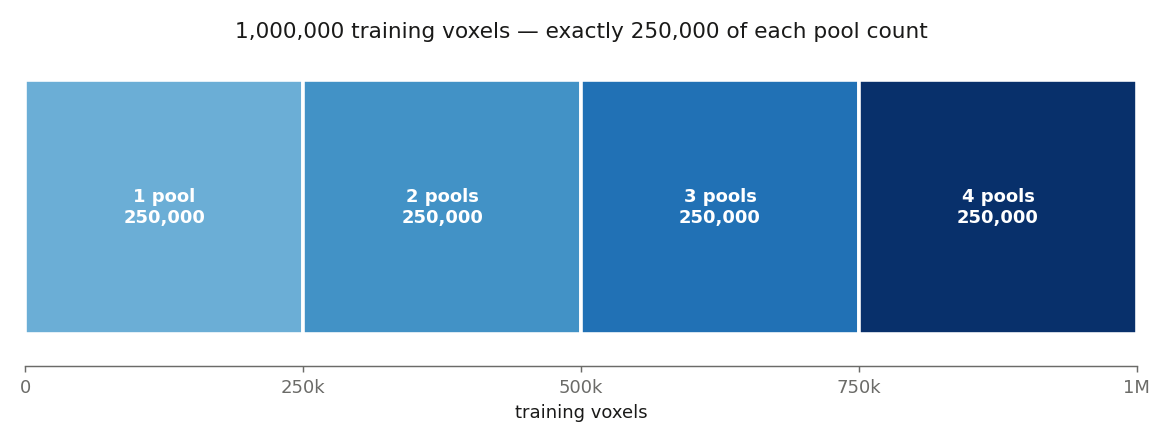

In [9]:
rows = []
for split in ("train", "val", "test"):
    per = [len(pd.read_parquet(DATA / f"n{n}" / f"{split}.parquet", columns=["n_comp"])) for n in (1,2,3,4)]
    rows.append({"split": split, **{f"{n} pools": f"{p:,}" for n, p in zip((1,2,3,4), per)},
                 "total": f"{sum(per):,}", "role": {"train": "the model learns from these",
                 "val": "when to stop; never trained on", "test": "the reported score; touched once"}[split]})
for snr in (20, 40, 60, 100, 150):
    per = [len(pd.read_parquet(DATA / f"n{n}" / f"test_snr{snr}.parquet", columns=["n_comp"])) for n in (1,2,3,4)]
    rows.append({"split": f"test @ SNR {snr}", **{f"{n} pools": f"{p:,}" for n, p in zip((1,2,3,4), per)},
                 "total": f"{sum(per):,}",
                 "role": "noise sweep" + (" (harder than training)" if snr == 20 else "")})
print(pd.DataFrame(rows).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 3.4))
tr = [len(pd.read_parquet(DATA / f"n{n}" / "train.parquet", columns=["n_comp"])) for n in (1,2,3,4)]
left = 0
for n, v in zip((1,2,3,4), tr):
    ax.barh([0], [v], left=left, color=NCOL[n], edgecolor="white", linewidth=2)
    ax.text(left + v/2, 0, f"{n} pool{'s' if n>1 else ''}\n{v:,}", ha="center", va="center",
            color="white", fontsize=10, fontweight="bold")
    left += v
ax.set(xlim=(0, left), ylim=(-0.5, 0.5), yticks=[], xlabel="training voxels",
       title=f"1,000,000 training voxels — exactly {tr[0]:,} of each pool count")
ax.set_xticks([0, 250_000, 500_000, 750_000, 1_000_000])
ax.set_xticklabels(["0", "250k", "500k", "750k", "1M"])
for s in ("left", "right", "top"): ax.spines[s].set_visible(False)
fig.tight_layout(); fig.savefig(FIG / "08_the_dataset.png", dpi=130); plt.close(fig)
Image(filename=str(FIG / "08_the_dataset.png"))

## So: what am I training on?

- **1,000,000 voxels**, exactly 250,000 each with 1, 2, 3 and 4 water pools.
- Each voxel = **64 signed numbers** (8 TI × 8 TE), the summed signal of its pools plus Gaussian
  noise at a random SNR between 30 and 150.
- Each pool = a random **(T1, T2, weight)**, T1 ∈ 50–4000 ms, T2 ∈ 5–3000 ms, T1 > T2, weight ≥ 5%.
  No tissue types — the task is *finding pools*, not recognising anatomy.
- **The model's job:** 64 numbers in → the set of pools out. How many, and each one's T1, T2 and
  weight.

**And the one thing to carry into every result:** at 4 pools, **69%** of voxels have a pool that is
invisible at SNR 20. So results are always read **per pool count**. A single average across 1–4
pools is not a result — it hides which regime the number came from.

---

*Correctness of this dataset is a separate question, checked by `full_data_audit.ipynb`
(39 checks, currently 39/39). This notebook is only about understanding it.*